# Fourier series, coefficient 

<div align="left">
<img src="https://www.researchgate.net/publication/323281289/figure/fig6/AS:701217198059529@1544194616847/Fast-Fourier-Transformation-2-Fast-Fourier-Transformation-To-increase-the-performance.ppm" width="400">
</div>



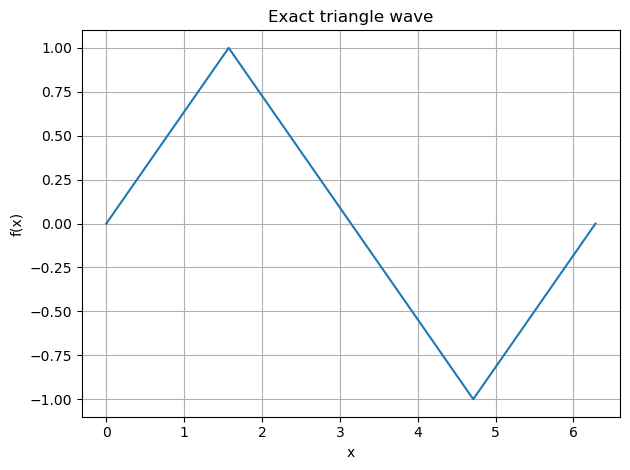

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# Triangle wave Fourier series: up to 6 odd harmonics
# ----------------------------------

# Domain (one period = 2π). Change to e.g. [-3*np.pi, 3*np.pi] to show more periods.
t = np.linspace(0.0, 2.0 * np.pi, 4000)

# Exact triangle wave with amplitude ±1 and period 2π
tri_exact = (2.0 / np.pi) * np.arcsin(np.sin(t))

# Plot once just to mimic the first simple plot (optional)
plt.figure()
plt.plot(t, tri_exact)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Exact triangle wave")
plt.grid(True)
plt.tight_layout()

In [4]:
import numpy as np

def fourier_coeffs_2pi(f, N, M=10000):
    """
    Compute Fourier series coefficients a0, an, bn for a 2π-periodic function f(x).
    
    f : callable, f(x) with x in [0, 2π]
    N : highest harmonic n
    M : number of sample points in [0, 2π)
    """
    # sample points
    x = np.linspace(0.0, 2.0*np.pi, M, endpoint=False)
    dx = x[1] - x[0]
    fx = f(x)
    
    # a0
    a0 = (1.0/np.pi) * np.sum(fx) * dx
    
    # an, bn
    n = np.arange(1, N+1)[:, None]     # shape (N,1) for broadcasting
    cos_nx = np.cos(n * x[None, :])    # shape (N,M)
    sin_nx = np.sin(n * x[None, :])    # shape (N,M)
    
    an = (1.0/np.pi) * np.sum(fx * cos_nx, axis=1) * dx  # shape (N,)
    bn = (1.0/np.pi) * np.sum(fx * sin_nx, axis=1) * dx  # shape (N,)
    
    return a0, an, bn


In [6]:
def reconstruct_from_coeffs(x, a0, an, bn):
    fN = a0 / 2.0 * np.ones_like(x)
    N = len(an)
    for n in range(1, N+1):
        fN += an[n-1] * np.cos(n * x) + bn[n-1] * np.sin(n * x)
    return fN


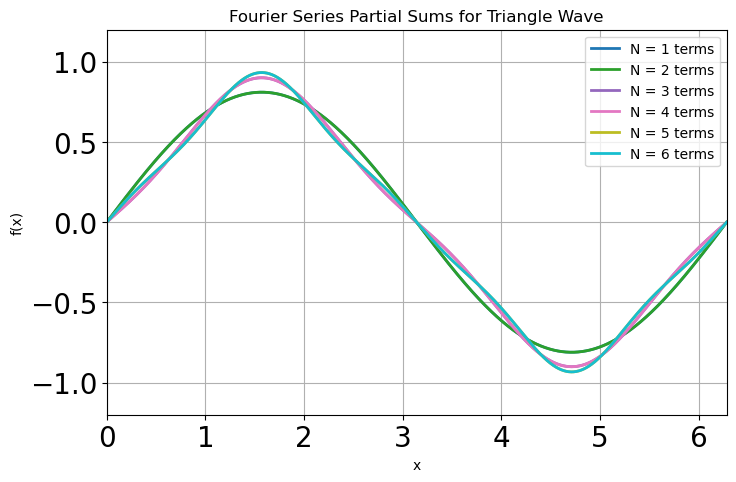

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- define the function you want to expand ---
def tri_exact(x):
    return (2/np.pi) * np.arcsin(np.sin(x))

# --- domain ---
t = np.linspace(0, 2*np.pi, 2000)

Nmax = 6
colors = plt.cm.tab10(np.linspace(0,1,Nmax))

plt.figure(figsize=(8,5))
plt.grid(True)
plt.box(True)

for N in range(1, Nmax + 1):

    # compute coefficients up to N
    a0, an, bn = fourier_coeffs_2pi(tri_exact, N)

    # reconstruct partial sum
    fN = reconstruct_from_coeffs(t, a0, an, bn)

    plt.plot(t, fN, color=colors[N-1], linewidth=2,
             label=f"N = {N} terms")

plt.ylim([-1.2, 1.2])
plt.xlim([t[0], t[-1]])
plt.gca().tick_params(labelsize=20)
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Fourier Series Partial Sums for Triangle Wave")

plt.show()


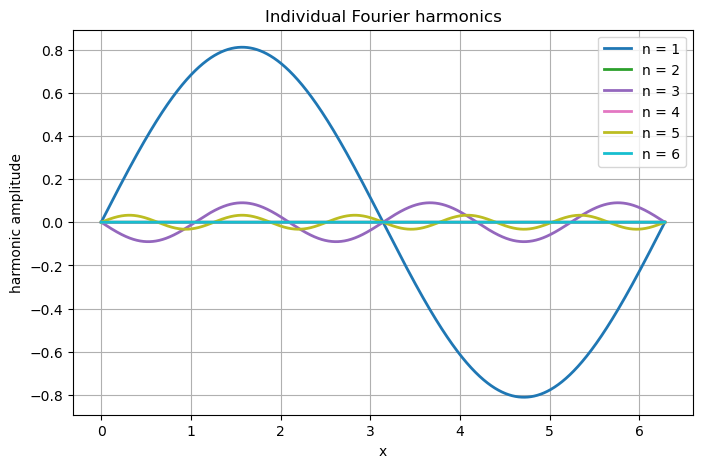

In [10]:
# ----------------------------------
# Figure 2: individual harmonics (for N = Nmax)
# ----------------------------------
import numpy as np
import matplotlib.pyplot as plt

# assume: a0, an, bn already computed, and t defined
# t = np.linspace(0, 2*np.pi, 2000)

plt.figure(figsize=(8,5))
plt.box(True)
plt.grid(True)

Nmax = 6
N = Nmax
a0, an, bn = fourier_coeffs_2pi(tri_exact, N)

N = len(an)
colors = plt.cm.tab10(np.linspace(0, 1, N))

for n in range(1, N+1):
    # single harmonic contribution:
    # f_n(x) = a_n cos(nx) + b_n sin(nx)
    fn = an[n-1] * np.cos(n * t) + bn[n-1] * np.sin(n * t)

    plt.plot(
        t,
        fn,
        color=colors[n-1],
        linewidth=2,
        label=f"n = {n}"
    )

plt.xlabel("x")
plt.ylabel("harmonic amplitude")
plt.title("Individual Fourier harmonics")
plt.legend()
plt.show()


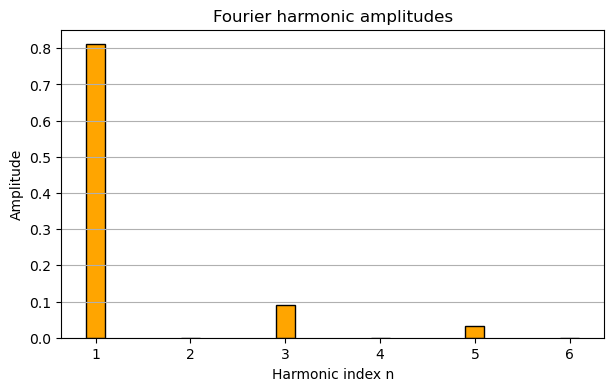

In [12]:

# ----------------------------------
# Figure 3: bar plot of Fourier amplitudes
# ----------------------------------

# Suppose an, bn already computed for n = 1..N
N = len(an)

harmonics = np.arange(1, N+1)
amp_vals = np.sqrt(an**2 + bn**2)

plt.figure(figsize=(7,4))
plt.bar(harmonics, amp_vals, width=0.2, color='orange', edgecolor='k')
plt.xlabel("Harmonic index n")
plt.ylabel("Amplitude")
plt.title("Fourier harmonic amplitudes")
plt.grid(axis='y')
plt.show()


